# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import bulk
from pathlib import Path
from ase.io import read, write
from ase.visualize import view
from ase.build import make_supercell
from ase.build import sort as ase_sort
import plotly.express as px
import plotly.graph_objects as go

# Stacking faults (Zinc Blende --> Wurtzite)

In [3]:
# Read the data
metal_of_interest = 'Fe'

# Zinc Blende structures
zincblende_structures = [str(filepath) for filepath in Path('./data/CIFs/').rglob('ZincBlende*.cif')]
zincblende_compositions = [filepath.split('/')[-1].split('_')[-1].split('.')[0] for filepath in zincblende_structures]
zincblende_metals = [composition[:-1] for composition in zincblende_compositions]

# Wurtzite structures
wurtzite_structures = [str(filepath) for filepath in Path('./data/CIFs/').rglob('Wurtzite*.cif')]
wurtzite_compositions = [filepath.split('/')[-1].split('_')[-1].split('.')[0] for filepath in wurtzite_structures]
wurtzite_metals = [composition[:-1] for composition in wurtzite_compositions]


In [4]:
# Papers that are relevant for the stacking faults
# https://pubs.rsc.org/en/content/articlelanding/2013/cp/c3cp00111c

# https://www.researchgate.net/publication/341183706_There's_no_place_like_real-space_Elucidating_size-dependent_atomic_structure_of_nanomaterials_using_Pair_Distribution_Function_analysis

# Filling holes (Rock Salt --> Spinel --> Zinc Blende)

In [3]:
# Define all possible fractional coordinates for a cubic cell

# Anion positions
anion_positions = np.array(
    [
        [0.0, 0.0, 0.0],
        [0.5, 0.5, 0.0],
        [0.5, 0.0, 0.5],
        [0.0, 0.5, 0.5],
    ]
)

# Cation positions

## Octahedral sites
octahedral_positions = np.array(
    [
        [0.5, 0.0, 0.0],
        [0.0, 0.5, 0.0],
        [0.0, 0.0, 0.5],
        [0.5, 0.5, 0.5],
    ]
)

## Tetrahedral sites
### T+ sites
tetrahedral_plus_positions = np.array(
    [
        [0.75, 0.25, 0.25],
        [0.25, 0.75, 0.25],
        [0.25, 0.25, 0.75],
        [0.75, 0.75, 0.75],
    ]
)

### T- sites
tetrahedral_minus_positions = np.array(
    [
        [0.25, 0.25, 0.25],
        [0.75, 0.75, 0.25],
        [0.25, 0.75, 0.75],
        [0.75, 0.25, 0.75],
    ]
)

In [4]:
# Define all possible fractional coordinates for the 2x2x2 supercell

anion_list = []
octahedral_list = []
tetrahedral_plus_list = []
tetrahedral_minus_list = []

for i in range(2):
    for j in range(2):
        for k in range(2):
            anion_list.append(anion_positions + [i, j, k])
            octahedral_list.append(octahedral_positions + [i, j, k])
            tetrahedral_plus_list.append(tetrahedral_plus_positions + [i, j, k])
            tetrahedral_minus_list.append(tetrahedral_minus_positions + [i, j, k])
            
anion_list = np.concatenate(anion_list) / 2
octahedral_list = np.concatenate(octahedral_list) / 2
tetrahedral_plus_list = np.concatenate(tetrahedral_plus_list) / 2
tetrahedral_minus_list = np.concatenate(tetrahedral_minus_list) / 2

# Make dataframe with all possible fractional coordinates
df_positions = pd.DataFrame(columns=["x", "y", "z", "origo_distance", "site"])
df_positions["x"] = np.concatenate(
    [anion_list[:, 0], octahedral_list[:, 0], tetrahedral_plus_list[:, 0], tetrahedral_minus_list[:, 0]]
)
df_positions["y"] = np.concatenate(
    [anion_list[:, 1], octahedral_list[:, 1], tetrahedral_plus_list[:, 1], tetrahedral_minus_list[:, 1]]
)
df_positions["z"] = np.concatenate(
    [anion_list[:, 2], octahedral_list[:, 2], tetrahedral_plus_list[:, 2], tetrahedral_minus_list[:, 2]]
)
df_positions["origo_distance"] = np.sqrt(df_positions["x"] ** 2 + df_positions["y"] ** 2 + df_positions["z"] ** 2)
df_positions["site"] = np.concatenate(
    [
        ["anion"] * len(anion_list),
        ["octahedral"] * len(octahedral_list),
        ["tetrahedral_plus"] * len(tetrahedral_plus_list),
        ["tetrahedral_minus"] * len(tetrahedral_minus_list),
    ]
)

# Sort dataframe by distance to origo, then by coordinate
df_positions = df_positions.sort_values(["origo_distance", "x", "y", "z"]).reset_index(drop=True)

# Print dataframe
df_positions.head()

,x,y,z,origo_distance,site
0,0.000,0.000,0.000,0.000000,anion
1,0.125,0.125,0.125,0.216506,tetrahedral_minus
2,0.000,0.000,0.250,0.250000,octahedral
3,0.000,0.250,0.000,0.250000,octahedral
4,0.250,0.000,0.000,0.250000,octahedral


In [5]:
# # Define the strucure endpoints

# # Rock salt: Only octahedral holes filled
# df_positions["Rock_salt"] = False
# df_positions.loc[df_positions["site"] == "anion", "Rock_salt"] = True
# df_positions.loc[df_positions["site"] == "octahedral", "Rock_salt"] = True

# # Zinc blende: Only one type of tetrahedral holes filled
# df_positions["Zinc_blende"] = False
# df_positions.loc[df_positions["site"] == "anion", "Zinc_blende"] = True
# df_positions.loc[df_positions["site"] == "tetrahedral_plus", "Zinc_blende"] = True

# # Spinel: Half of octahedral holes filled and half of each type of tetrahedral holes filled
# df_positions["Spinel"] = False
# df_positions.loc[df_positions["site"] == "anion", "Spinel"] = True


In [6]:
# # Show all possible sites in a 3D plot using plotly
# fig = px.scatter_3d(
#     df_positions,
#     x="x",
#     y="y",
#     z="z",
#     color="site",
#     width=800,
#     height=800,
# )

# fig.update_traces(marker=dict(size=5))

# # Make plot limits between -0.1 and 1.1
# fig.update_layout(
#     scene=dict(
#         xaxis=dict(range=[-0.1, 1.1]),
#         yaxis=dict(range=[-0.1, 1.1]),
#         zaxis=dict(range=[-0.1, 1.1]),
#     )
# )

# fig.show()

In [7]:
# Rock Salt structures
rocksalt_structures = [str(filepath) for filepath in Path('./data/CIFs/').rglob('RockSalt*.cif')]
rocksalt_compositions = [filepath.split('/')[-1].split('_')[-1].split('.')[0] for filepath in rocksalt_structures]
rocksalt_metals = [composition[:-1] for composition in rocksalt_compositions]

# Spinel structures
spinel_structures = [str(filepath) for filepath in Path('./data/CIFs/').rglob('Spinel*.cif')]
spinel_compositions = [filepath.split('/')[-1].split('_')[-1].split('.')[0] for filepath in spinel_structures]
spinel_metals = [composition[: len(composition[:-3]) // 2] for composition in spinel_compositions]

# Zinc Blende structures
zincblende_structures = [str(filepath) for filepath in Path('./data/CIFs/').rglob('ZincBlende*.cif')]
zincblende_compositions = [filepath.split('/')[-1].split('_')[-1].split('.')[0] for filepath in zincblende_structures]
zincblende_metals = [composition[:-1] for composition in zincblende_compositions]


In [8]:
def rocksalt_transformation(rocksalt_unitcell, expansion_factor=2, translation=0.25, inversion=False):
    # Make a supercell of the unit cell
    rocksalt_supercell = make_supercell(rocksalt_unitcell, np.diag([expansion_factor, expansion_factor, expansion_factor]))

    if inversion:
        # Invert the atoms in the supercell
        rocksalt_supercell.set_scaled_positions(1 - rocksalt_supercell.get_scaled_positions())

    # Translate the atoms in the supercell
    rocksalt_supercell.set_scaled_positions(rocksalt_supercell.get_scaled_positions() + translation) 
    
    return rocksalt_supercell

def spinel_transformation(spinel_unitcell, expansion_factor=1, translation=0.0, inversion=False):
    # Make a supercell of the unit cell
    spinel_supercell = make_supercell(spinel_unitcell, np.diag([expansion_factor, expansion_factor, expansion_factor]))
    
    if inversion:
        # Invert the atoms in the supercell
        spinel_supercell.set_scaled_positions(1 - spinel_supercell.get_scaled_positions())

    # Translate the atoms in the supercell
    spinel_supercell.set_scaled_positions(spinel_supercell.get_scaled_positions() + translation) 
    
    return spinel_supercell

def zincblende_transformation(zincblende_unitcell, expansion_factor=2,  translation=0.0, inversion=True):
    # Make a supercell of the unit cell
    zincblende_supercell = make_supercell(zincblende_unitcell, np.diag([expansion_factor, expansion_factor, expansion_factor]))
    
    if inversion:
        # Invert the atoms in the supercell
        zincblende_supercell.set_scaled_positions(1 - zincblende_supercell.get_scaled_positions())

    # Translate the atoms in the supercell
    zincblende_supercell.set_scaled_positions(zincblende_supercell.get_scaled_positions() + translation) 
    
    return zincblende_supercell

def standardize_structure(structure, df_reference):
    structure_positions = structure.get_scaled_positions()
    structure_atoms = structure.get_atomic_numbers()
        
    reference_positions = df_reference[['x', 'y', 'z']].values

    new_positions = np.zeros_like(reference_positions) - 1.
    new_atoms = np.zeros_like(df_reference['site'].values)

    for atom, position in zip(structure_atoms, structure_positions):
        distances = np.linalg.norm(reference_positions - position, axis=1)
        idx = np.argmin(distances)
        new_positions[idx] = position
        new_atoms[idx] = atom
    
    return new_atoms, new_positions

In [138]:
# Read and visualize the structures for the same metal

metal_of_interest = 'Fe'

# Rock Salt
rocksalt_structure = read(rocksalt_structures[rocksalt_metals.index(metal_of_interest)])
rocksalt_transformed = rocksalt_transformation(rocksalt_structure, translation=0.25)

# Spinel
spinel_structure = read(spinel_structures[spinel_metals.index(metal_of_interest)])
spinel_transformed = spinel_transformation(spinel_structure, translation=0.1374, inversion=False) # 0.1374

# Zinc Blende
zincblende_structure = read(zincblende_structures[zincblende_metals.index(metal_of_interest)])
zincblende_transformed = zincblende_transformation(zincblende_structure, inversion=True, translation=0.125)

In [10]:
# Put the rock salt structure into the defined positions
rocksalt_atoms, rocksalt_positions = standardize_structure(rocksalt_transformed, df_positions)

# Put the spinel structure into the defined positions
spinel_atoms, spinel_positions = standardize_structure(spinel_transformed, df_positions)
spinel_positions[spinel_atoms != 0] -= 0.0124

# Put the zinc blende structure into the defined positions
zincblende_atoms, zincblende_positions = standardize_structure(zincblende_transformed, df_positions)

In [11]:
# Print the fraction of each site occupied in the structure
rocksalt_fraction_anion_sites = len(rocksalt_atoms[(df_positions['site'] == 'anion') & (rocksalt_atoms == 8)]) / len(rocksalt_atoms[df_positions['site'] == 'anion'])
rocksalt_fraction_octahedral_sites = len(rocksalt_atoms[(df_positions['site'] == 'octahedral') & (rocksalt_atoms == 26)]) / len(rocksalt_atoms[df_positions['site'] == 'octahedral'])
rocksalt_fraction_tetrahedral_plus_sites = len(rocksalt_atoms[(df_positions['site'] == 'tetrahedral_plus') & (rocksalt_atoms == 26)]) / len(rocksalt_atoms[df_positions['site'] == 'tetrahedral_plus'])
rocksalt_fraction_tetrahedral_minus_sites = len(rocksalt_atoms[(df_positions['site'] == 'tetrahedral_minus') & (rocksalt_atoms == 26)]) / len(rocksalt_atoms[df_positions['site'] == 'tetrahedral_minus'])
rocksalt_fraction_tetrahedral_sites = rocksalt_fraction_tetrahedral_plus_sites + rocksalt_fraction_tetrahedral_minus_sites

print("Rock Salt:")
print(f"Fraction of anion sites occupied: {rocksalt_fraction_anion_sites:.2f} (N = {len(rocksalt_atoms[(df_positions['site'] == 'anion') & (rocksalt_atoms == 8)])})")
print(f"Fraction of octahedral sites occupied: {rocksalt_fraction_octahedral_sites:.2f} (N = {len(rocksalt_atoms[(df_positions['site'] == 'octahedral') & (rocksalt_atoms == 26)])})")
print(f"Fraction of tetrahedral sites occupied: {rocksalt_fraction_tetrahedral_sites:.2f} [T+ sites: {rocksalt_fraction_tetrahedral_plus_sites:.2f}, T- sites: {rocksalt_fraction_tetrahedral_minus_sites:.2f}]")

spinel_fraction_anion_sites = len(spinel_atoms[(df_positions['site'] == 'anion') & (spinel_atoms == 8)]) / len(spinel_atoms[df_positions['site'] == 'anion'])
spinel_fraction_octahedral_sites = len(spinel_atoms[(df_positions['site'] == 'octahedral') & (spinel_atoms == 26)]) / len(spinel_atoms[df_positions['site'] == 'octahedral'])
spinel_fraction_tetrahedral_plus_sites = len(spinel_atoms[(df_positions['site'] == 'tetrahedral_plus') & (spinel_atoms == 26)]) / len(spinel_atoms[df_positions['site'] == 'tetrahedral_plus'])
spinel_fraction_tetrahedral_minus_sites = len(spinel_atoms[(df_positions['site'] == 'tetrahedral_minus') & (spinel_atoms == 26)]) / len(spinel_atoms[df_positions['site'] == 'tetrahedral_minus'])
spinel_fraction_tetrahedral_sites = spinel_fraction_tetrahedral_plus_sites + spinel_fraction_tetrahedral_minus_sites

print("\nSpinel:")
print(f"Fraction of anion sites occupied: {spinel_fraction_anion_sites:.2f}")
print(f"Fraction of octahedral sites occupied: {spinel_fraction_octahedral_sites:.2f} (N = {len(spinel_atoms[(df_positions['site'] == 'octahedral') & (spinel_atoms == 26)])})")
print(f"Fraction of tetrahedral sites occupied: {spinel_fraction_tetrahedral_sites:.2f} (T+ sites: {spinel_fraction_tetrahedral_plus_sites:.3f}, T- sites: {spinel_fraction_tetrahedral_minus_sites:.3f})")

zincblende_fraction_anion_sites = len(zincblende_atoms[(df_positions['site'] == 'anion') & (zincblende_atoms == 8)]) / len(zincblende_atoms[df_positions['site'] == 'anion'])
zincblende_fraction_octahedral_sites = len(zincblende_atoms[(df_positions['site'] == 'octahedral') & (zincblende_atoms == 26)]) / len(zincblende_atoms[df_positions['site'] == 'octahedral'])
zincblende_fraction_tetrahedral_plus_sites = len(zincblende_atoms[(df_positions['site'] == 'tetrahedral_plus') & (zincblende_atoms == 26)]) / len(zincblende_atoms[df_positions['site'] == 'tetrahedral_plus'])
zincblende_fraction_tetrahedral_minus_sites = len(zincblende_atoms[(df_positions['site'] == 'tetrahedral_minus') & (zincblende_atoms == 26)]) / len(zincblende_atoms[df_positions['site'] == 'tetrahedral_minus'])
zincblende_fraction_tetrahedral_sites = zincblende_fraction_tetrahedral_plus_sites + zincblende_fraction_tetrahedral_minus_sites

print("\nZinc Blende:")
print(f"Fraction of anion sites occupied: {zincblende_fraction_anion_sites:.2f}")
print(f"Fraction of octahedral sites occupied: {zincblende_fraction_octahedral_sites:.2f}")
print(f"Fraction of tetrahedral sites occupied: {zincblende_fraction_tetrahedral_sites:.2f} (T+ sites: {zincblende_fraction_tetrahedral_plus_sites:.2f}, T- sites: {zincblende_fraction_tetrahedral_minus_sites:.2f})")


Rock Salt:
Fraction of anion sites occupied: 1.00 (N = 32)
Fraction of octahedral sites occupied: 1.00 (N = 32)
Fraction of tetrahedral sites occupied: 0.00 [T+ sites: 0.00, T- sites: 0.00]

Spinel:
Fraction of anion sites occupied: 1.00
Fraction of octahedral sites occupied: 0.50 (N = 16)
Fraction of tetrahedral sites occupied: 0.25 (T+ sites: 0.125, T- sites: 0.125)

Zinc Blende:
Fraction of anion sites occupied: 1.00
Fraction of octahedral sites occupied: 0.00
Fraction of tetrahedral sites occupied: 1.00 (T+ sites: 0.00, T- sites: 1.00)


In [12]:
for i in range(len(rocksalt_atoms)):
    print(rocksalt_positions[i], rocksalt_atoms[i], df_positions["site"][i])

[0. 0. 0.] 8 anion
[-1. -1. -1.] 0 tetrahedral_minus
[0.   0.   0.25] 26 octahedral
[0.   0.25 0.  ] 26 octahedral
[0.25 0.   0.  ] 26 octahedral
[0.   0.25 0.25] 8 anion
[0.25 0.   0.25] 8 anion
[0.25 0.25 0.  ] 8 anion
[-1. -1. -1.] 0 tetrahedral_plus
[-1. -1. -1.] 0 tetrahedral_plus
[-1. -1. -1.] 0 tetrahedral_plus
[0.25 0.25 0.25] 26 octahedral
[0.  0.  0.5] 8 anion
[0.  0.5 0. ] 8 anion
[0.5 0.  0. ] 8 anion
[-1. -1. -1.] 0 tetrahedral_minus
[-1. -1. -1.] 0 tetrahedral_minus
[-1. -1. -1.] 0 tetrahedral_minus
[0.   0.25 0.5 ] 26 octahedral
[0.   0.5  0.25] 26 octahedral
[0.25 0.   0.5 ] 26 octahedral
[0.25 0.5  0.  ] 26 octahedral
[0.5  0.   0.25] 26 octahedral
[0.5  0.25 0.  ] 26 octahedral
[0.25 0.25 0.5 ] 8 anion
[0.25 0.5  0.25] 8 anion
[0.5  0.25 0.25] 8 anion
[-1. -1. -1.] 0 tetrahedral_minus
[-1. -1. -1.] 0 tetrahedral_minus
[-1. -1. -1.] 0 tetrahedral_plus
[-1. -1. -1.] 0 tetrahedral_minus
[0.  0.5 0.5] 8 anion
[0.5 0.  0.5] 8 anion
[0.5 0.5 0. ] 8 anion
[-1. -1. -1.] 0 tet

In [13]:
for i in range(len(spinel_atoms)):
    print(spinel_positions[i], spinel_atoms[i], df_positions["site"][i])

[0.0124 0.0124 0.0124] 8 anion
[-1. -1. -1.] 0 tetrahedral_minus
[-3.2959746e-17 -3.2959746e-17  2.5000000e-01] 26 octahedral
[-3.2959746e-17  2.5000000e-01 -3.2959746e-17] 26 octahedral
[ 2.5000000e-01 -3.2959746e-17 -3.2959746e-17] 26 octahedral
[0.0124 0.2376 0.2376] 8 anion
[0.2376 0.0124 0.2376] 8 anion
[0.2376 0.2376 0.0124] 8 anion
[-1. -1. -1.] 0 tetrahedral_plus
[-1. -1. -1.] 0 tetrahedral_plus
[-1. -1. -1.] 0 tetrahedral_plus
[0.25 0.25 0.25] 26 octahedral
[-0.0124 -0.0124  0.4876] 8 anion
[-0.0124  0.4876 -0.0124] 8 anion
[ 0.4876 -0.0124 -0.0124] 8 anion
[-1. -1. -1.] 0 tetrahedral_minus
[-1. -1. -1.] 0 tetrahedral_minus
[-1. -1. -1.] 0 tetrahedral_minus
[-1. -1. -1.] 0 octahedral
[-1. -1. -1.] 0 octahedral
[-1. -1. -1.] 0 octahedral
[-1. -1. -1.] 0 octahedral
[-1. -1. -1.] 0 octahedral
[-1. -1. -1.] 0 octahedral
[0.2624 0.2624 0.4876] 8 anion
[0.2624 0.4876 0.2624] 8 anion
[0.4876 0.2624 0.2624] 8 anion
[0.125 0.125 0.625] 26 tetrahedral_minus
[0.125 0.625 0.125] 26 tetrah

In [14]:
for i in range(len(zincblende_atoms)):
    print(zincblende_positions[i], zincblende_atoms[i], df_positions["site"][i])

[0. 0. 0.] 8 anion
[0.125 0.125 0.125] 26 tetrahedral_minus
[-1. -1. -1.] 0 octahedral
[-1. -1. -1.] 0 octahedral
[-1. -1. -1.] 0 octahedral
[0.   0.25 0.25] 8 anion
[0.25 0.   0.25] 8 anion
[0.25 0.25 0.  ] 8 anion
[-1. -1. -1.] 0 tetrahedral_plus
[-1. -1. -1.] 0 tetrahedral_plus
[-1. -1. -1.] 0 tetrahedral_plus
[-1. -1. -1.] 0 octahedral
[0.  0.  0.5] 8 anion
[0.  0.5 0. ] 8 anion
[0.5 0.  0. ] 8 anion
[0.125 0.375 0.375] 26 tetrahedral_minus
[0.375 0.125 0.375] 26 tetrahedral_minus
[0.375 0.375 0.125] 26 tetrahedral_minus
[-1. -1. -1.] 0 octahedral
[-1. -1. -1.] 0 octahedral
[-1. -1. -1.] 0 octahedral
[-1. -1. -1.] 0 octahedral
[-1. -1. -1.] 0 octahedral
[-1. -1. -1.] 0 octahedral
[0.25 0.25 0.5 ] 8 anion
[0.25 0.5  0.25] 8 anion
[0.5  0.25 0.25] 8 anion
[0.125 0.125 0.625] 26 tetrahedral_minus
[0.125 0.625 0.125] 26 tetrahedral_minus
[-1. -1. -1.] 0 tetrahedral_plus
[0.625 0.125 0.125] 26 tetrahedral_minus
[0.  0.5 0.5] 8 anion
[0.5 0.  0.5] 8 anion
[0.5 0.5 0. ] 8 anion
[-1. -1. -

In [15]:
write('rocksalt_test.cif', rocksalt_transformed)
write('spinel_test.cif', spinel_structure)
write('zincblende_test.cif', zincblende_transformed)

In [16]:
len(rocksalt_transformed), len(spinel_structure), len(zincblende_transformed)

(64, 56, 64)

In [17]:
# view([rocksalt_transformed, spinel_structure, zincblende_transformed], viewer='ngl')

In [132]:
def sigmoid_function(x, center=0.5, steepness=10):
    return 1 / (1 + np.exp(-steepness * (x - center)))

In [ ]:
# Define interpolation functions for the structures
def rocksalt_to_spinel(rocksalt_structure, spinel_structure, interpolation_steps=10, atom_samples=5, identification_threshold=0.1):
    # Sort the atoms
    rocksalt_structure = ase_sort(rocksalt_structure, tags=rocksalt_structure.get_atomic_numbers())
    spinel_structure = ase_sort(spinel_structure, tags=spinel_structure.get_atomic_numbers())    
    
    # Get cell parameters
    rocksalt_cell_parameters = rocksalt_structure.cell.cellpar()
    spinel_cell_parameters = spinel_structure.cell.cellpar()
    
    # Get the scaled positions of the atoms
    rocksalt_positions = rocksalt_structure.get_scaled_positions()
    spinel_positions = spinel_structure.get_scaled_positions()
    
    # Get the atomic numbers of the atoms
    rocksalt_atoms = rocksalt_structure.get_atomic_numbers()
    spinel_atoms = spinel_structure.get_atomic_numbers()
    
    # Find the positions of the oxygen atoms
    rocksalt_O_positions = rocksalt_positions[rocksalt_atoms == 8]
    spinel_O_positions = spinel_positions[spinel_atoms == 8]
    
    # Sort the oxygen atoms by distance to the origo and then by coordinate TODO: Do this
    temp_O_df = pd.DataFrame(rocksalt_O_positions, columns=['x', 'y', 'z'])
    temp_O_df['distance'] = np.linalg.norm(rocksalt_O_positions, axis=1)
    rocksalt_O_positions = rocksalt_O_positions[temp_O_df.sort_values(['distance', 'x', 'y', 'z']).index]
    
    temp_O_df = pd.DataFrame(spinel_O_positions, columns=['x', 'y', 'z'])
    temp_O_df['distance'] = np.linalg.norm(spinel_O_positions, axis=1)
    spinel_O_positions = spinel_O_positions[temp_O_df.sort_values(['distance', 'x', 'y', 'z']).index]

    del temp_O_df
    
    # Find the positions of the metal atoms
    rocksalt_M_positions = rocksalt_positions[rocksalt_atoms != 8]
    spinel_M_positions = spinel_positions[spinel_atoms != 8]
    
    # Structure metallic element
    metallic_element = rocksalt_structure.get_atomic_numbers()[-1]
    
    # Find the metal atoms that are in both the rocksalt structure and the spinel structure
    rocksalt_common_M_positions = []
    spinel_common_M_positions = []
    for index in range(len(rocksalt_M_positions)):
        distances = np.linalg.norm(spinel_M_positions - rocksalt_M_positions[index], axis=1)
        if np.min(distances) < identification_threshold:
            rocksalt_common_M_positions.append(index)
            spinel_common_M_positions.append(np.argmin(distances))
            
    rocksalt_different_M_positions = [index for index in range(len(rocksalt_M_positions)) if index not in rocksalt_common_M_positions]
    spinel_different_M_positions = [index for index in range(len(spinel_M_positions)) if index not in spinel_common_M_positions]
    
    interp_step_list = []
    sample_i_list = []
    interpolated_cell_parameters_list = []
    interpolated_atoms_list = []
    interpolated_positions_list = []
    for interp_step_i in range(interpolation_steps + 1):
        if interp_step_i == 0:
            # Save the rocksalt structure
            interp_step_list.append(interp_step_i)
            sample_i_list.append(0)
            interpolated_cell_parameters_list.append(rocksalt_cell_parameters)
            interpolated_atoms_list.append(rocksalt_atoms)
            interpolated_positions_list.append(rocksalt_positions)
            continue
        elif interp_step_i == interpolation_steps:
            # Save the spinel structure
            interp_step_list.append(interp_step_i)
            sample_i_list.append(0)
            interpolated_cell_parameters_list.append(spinel_cell_parameters)
            interpolated_atoms_list.append(spinel_atoms)
            interpolated_positions_list.append(spinel_positions)
            continue
        else:
            # Interpolate the cell parameters 
            interpolated_cell_parameters = rocksalt_cell_parameters + (spinel_cell_parameters - rocksalt_cell_parameters) * sigmoid_function(interp_step_i / interpolation_steps, center=0.6, steepness=10)
            
            # Interpolate the positions of oxygens
            interpolated_O_positions = rocksalt_O_positions + (spinel_O_positions - rocksalt_O_positions) * sigmoid_function(interp_step_i / interpolation_steps, center=0.6, steepness=10)
            # interpolated_O_list.append(interpolated_O_positions)
            
            # Interpolate the positions of the common metal atoms
            interpolated_common_M_positions = rocksalt_M_positions[rocksalt_common_M_positions] + (spinel_M_positions[spinel_common_M_positions] - rocksalt_M_positions[rocksalt_common_M_positions]) * interp_step_i / interpolation_steps
            # interpolated_common_M_list.append(interpolated_common_M_positions)
            
            for sample_i in range(atom_samples):                            
                # Non-shared metal atoms from rock salt to keep
                n_rocksalt_different_M_positions = len(rocksalt_different_M_positions)
                
                # sigmoid probability for keeping an atom
                p_1 = 1 - sigmoid_function(interp_step_i / interpolation_steps, center=0.4, steepness=10)
                
                rocksalt_indeces_to_keep = np.where(np.random.random(n_rocksalt_different_M_positions) < p_1)[0]
                
                # # Determine how many atoms to remove
                # n_to_remove = sum(np.random.random(n_rocksalt_different_M_positions) > p_1)

                # # Choose which atoms to remove in a spatially aware way
                # indeces_to_remove = []
                # removed_positions = []
                # for i in range(n_to_remove):
                #     if i == 0:
                #         # Completely random choice
                #         index = np.random.choice(range(n_rocksalt_different_M_positions))
                #         indeces_to_remove.append(index)
                #         removed_positions.append(rocksalt_M_positions[rocksalt_different_M_positions[index]])
                #     else:
                #         # Calculate sum of distances to removed atoms
                #         distances = np.zeros(n_rocksalt_different_M_positions)
                #         for position in removed_positions:
                #             distances += np.linalg.norm(rocksalt_M_positions[rocksalt_different_M_positions] - position, axis=1)
                            
                #         # Calculate probability of removing each atom based on distance to removed atoms and set the probability of removing already removed atoms to zero
                #         for indeces_to_remove_i in indeces_to_remove:
                #             distances[indeces_to_remove_i] = 0
                #         p_distance = distances / np.sum(distances)

                #         # Choose the atom to remove
                #         index = np.random.choice(range(n_rocksalt_different_M_positions), p=p_distance)

                #         indeces_to_remove.append(index)
                #         removed_positions.append(rocksalt_M_positions[rocksalt_different_M_positions[index]])
                        
                # rocksalt_indeces_to_keep = np.zeros_like(rocksalt_different_M_positions) + 1
                # rocksalt_indeces_to_keep[indeces_to_remove] = 0
                 

                interpolated_different_M_positions = rocksalt_M_positions[rocksalt_different_M_positions][rocksalt_indeces_to_keep]
            
                # Non-shared metal atoms from spinel to add
                # sigmoid probability for adding the atom
                p_2 = sigmoid_function(interp_step_i / interpolation_steps, center=0.6, steepness=10)
                
                spinel_indeces_to_add = np.where(np.random.random(len(spinel_different_M_positions)) < p_2)[0]
                
                # Check that there are not more atoms to add than there are atoms to remove
                if len(spinel_indeces_to_add) > n_rocksalt_different_M_positions - len(rocksalt_indeces_to_keep):
                    spinel_indeces_to_add = np.random.choice(spinel_indeces_to_add, n_rocksalt_different_M_positions - len(rocksalt_indeces_to_keep), replace=False)
                
                interpolated_different_M_positions = np.concatenate([interpolated_different_M_positions, spinel_M_positions[spinel_different_M_positions][spinel_indeces_to_add]])
                
                # Construct the interpolated structure
                interpolated_atoms = np.concatenate(
                    [
                        [8] * len(interpolated_O_positions),
                        [metallic_element] * len(interpolated_common_M_positions),
                        [metallic_element] * len(interpolated_different_M_positions)
                        ]
                    )
                interpolated_positions = np.concatenate(
                    [
                        interpolated_O_positions, 
                        interpolated_common_M_positions, 
                        interpolated_different_M_positions, 
                    ]
                )
                
                # Save the interpolated structure
                interp_step_list.append(interp_step_i)
                sample_i_list.append(sample_i)
                interpolated_cell_parameters_list.append(interpolated_cell_parameters)
                interpolated_atoms_list.append(interpolated_atoms)
                interpolated_positions_list.append(interpolated_positions)  
        
    return interp_step_list, sample_i_list, interpolated_cell_parameters_list, interpolated_atoms_list, interpolated_positions_list


In [ ]:
def zincblende_to_spinel(zincblende_structure, spinel_structure, interpolation_steps=10, atom_samples=5, identification_threshold=0.1):
    # Sort the atoms
    zincblende_structure = ase_sort(zincblende_structure, tags=zincblende_structure.get_atomic_numbers())
    spinel_structure = ase_sort(spinel_structure, tags=spinel_structure.get_atomic_numbers())    
    
    # Get cell parameters
    zincblende_cell_parameters = zincblende_structure.cell.cellpar()
    spinel_cell_parameters = spinel_structure.cell.cellpar()
    
    # Get the scaled positions of the atoms
    zincblende_positions = zincblende_structure.get_scaled_positions()
    spinel_positions = spinel_structure.get_scaled_positions()
    
    # Get the atomic numbers of the atoms
    zincblende_atoms = zincblende_structure.get_atomic_numbers()
    spinel_atoms = spinel_structure.get_atomic_numbers()
    
    # Find the positions of the oxygen atoms
    zincblende_O_positions = zincblende_positions[zincblende_atoms == 8]
    spinel_O_positions = spinel_positions[spinel_atoms == 8]
    
    # Sort the oxygen atoms by distance to the origo and then by coordinate TODO: Do this
    temp_O_df = pd.DataFrame(zincblende_O_positions, columns=['x', 'y', 'z'])
    temp_O_df['distance'] = np.linalg.norm(zincblende_O_positions, axis=1)
    zincblende_O_positions = zincblende_O_positions[temp_O_df.sort_values(['distance', 'x', 'y', 'z']).index]
    
    temp_O_df = pd.DataFrame(spinel_O_positions, columns=['x', 'y', 'z'])
    temp_O_df['distance'] = np.linalg.norm(spinel_O_positions, axis=1)
    spinel_O_positions = spinel_O_positions[temp_O_df.sort_values(['distance', 'x', 'y', 'z']).index]

    del temp_O_df
    
    # Find the positions of the metal atoms
    zincblende_M_positions = zincblende_positions[zincblende_atoms != 8]
    spinel_M_positions = spinel_positions[spinel_atoms != 8]
    
    # Structure metallic element
    metallic_element = zincblende_structure.get_atomic_numbers()[-1]
    
    # Find the metal atoms that are in both the zincblende structure and the spinel structure
    zincblende_common_M_positions = []
    spinel_common_M_positions = []
    for index in range(len(zincblende_M_positions)):
        distances = np.linalg.norm(spinel_M_positions - zincblende_M_positions[index], axis=1)
        if np.min(distances) < identification_threshold:
            zincblende_common_M_positions.append(index)
            spinel_common_M_positions.append(np.argmin(distances))
            
    zincblende_different_M_positions = [index for index in range(len(zincblende_M_positions)) if index not in zincblende_common_M_positions]
    spinel_different_M_positions = [index for index in range(len(spinel_M_positions)) if index not in spinel_common_M_positions]
    
    interp_step_list = []
    sample_i_list = []
    interpolated_cell_parameters_list = []
    interpolated_atoms_list = []
    interpolated_positions_list = []
    
    for interp_step_i in range(interpolation_steps + 1):
        if interp_step_i == 0:
            # Save the zincblende structure
            interp_step_list.append(interp_step_i)
            sample_i_list.append(0)
            interpolated_cell_parameters_list.append(zincblende_cell_parameters)
            interpolated_atoms_list.append(zincblende_atoms)
            interpolated_positions_list.append(zincblende_positions)
            continue
        elif interp_step_i == interpolation_steps:
            # Save the spinel structure
            interp_step_list.append(interp_step_i)
            sample_i_list.append(0)
            interpolated_cell_parameters_list.append(spinel_cell_parameters)
            interpolated_atoms_list.append(spinel_atoms)
            interpolated_positions_list.append(spinel_positions)
            continue
        else:
            # Interpolate the cell parameters 
            interpolated_cell_parameters = zincblende_cell_parameters + (spinel_cell_parameters - zincblende_cell_parameters) * sigmoid_function(interp_step_i / interpolation_steps, center=0.6, steepness=10)
            
            # Interpolate the positions of oxygens
            interpolated_O_positions = zincblende_O_positions + (spinel_O_positions - zincblende_O_positions) * sigmoid_function(interp_step_i / interpolation_steps, center=0.6, steepness=10)
            # interpolated_O_list.append(interpolated_O_positions)
            
            # Interpolate the positions of the common metal atoms
            interpolated_common_M_positions = zincblende_M_positions[zincblende_common_M_positions] + (spinel_M_positions[spinel_common_M_positions] - zincblende_M_positions[zincblende_common_M_positions]) * interp_step_i / interpolation_steps
            # interpolated_common_M_list.append(interpolated_common_M_positions)
            
            for sample_i in range(atom_samples):                           
                # Non-shared metal atoms from zincblende to keep
                n_zincblende_different_M_positions = len(zincblende_different_M_positions)
                
                p_1 = 1 - sigmoid_function(interp_step_i / interpolation_steps, center=0.4, steepness=10)
                
                zincblende_indeces_to_keep = np.where(np.random.random(n_zincblende_different_M_positions) < p_1)[0]
                
                interpolated_different_M_positions = zincblende_M_positions[zincblende_different_M_positions][zincblende_indeces_to_keep]
            
                # Non-shared metal atoms from spinel to add
                p_2 = sigmoid_function(interp_step_i / interpolation_steps, center=0.6, steepness=10)
                
                spinel_indeces_to_add = np.where(np.random.random(len(spinel_different_M_positions)) < p_2)[0]
                
                # Check that there are not more atoms to add than there are atoms to remove
                if len(spinel_indeces_to_add) > n_zincblende_different_M_positions - len(zincblende_indeces_to_keep):
                    spinel_indeces_to_add = np.random.choice(spinel_indeces_to_add, n_zincblende_different_M_positions - len(zincblende_indeces_to_keep), replace=False)
                
                interpolated_different_M_positions = np.concatenate([interpolated_different_M_positions, spinel_M_positions[spinel_different_M_positions][spinel_indeces_to_add]])
                
                # Construct the interpolated structure
                interpolated_atoms = np.concatenate(
                    [
                        [8] * len(interpolated_O_positions),
                        [metallic_element] * len(interpolated_common_M_positions),
                        [metallic_element] * len(interpolated_different_M_positions)
                        ]
                    )
                interpolated_positions = np.concatenate(
                    [
                        interpolated_O_positions, 
                        interpolated_common_M_positions, 
                        interpolated_different_M_positions, 
                    ]
                )
                
                # Save the interpolated structure
                interp_step_list.append(interp_step_i)
                sample_i_list.append(sample_i)
                interpolated_cell_parameters_list.append(interpolated_cell_parameters)
                interpolated_atoms_list.append(interpolated_atoms)
                interpolated_positions_list.append(interpolated_positions)
    
    return interp_step_list, sample_i_list, interpolated_cell_parameters_list, interpolated_atoms_list, interpolated_positions_list

In [143]:
# Define save folder
save_folder = './data/CIFs/Interpolations/'

Path(save_folder).mkdir(parents=True, exist_ok=True)

# Determine random seed
seed = 42
np.random.seed(seed)

# Generate rocksalt to spinel interpolations
interp_step_list, sample_i_list, interpolated_cell_parameters_list, interpolated_atoms_list, interpolated_positions_list = rocksalt_to_spinel(rocksalt_transformed, spinel_transformed, identification_threshold=0.1)

# Check for and remove duplicate structures
duplicate_indices = []
for i in range(len(interp_step_list)):
    for j in range(i, len(interp_step_list)):
        if i == j:
            continue
        if np.array_equal(interpolated_positions_list[i], interpolated_positions_list[j]) and np.array_equal(interpolated_cell_parameters_list[i], interpolated_cell_parameters_list[j]):
            if j == len(interp_step_list) - 1:
                duplicate_indices.append(i)
            else:
                duplicate_indices.append(j)

interp_step_list = [interp_step_list[i] for i in range(len(interp_step_list)) if i not in duplicate_indices]
sample_i_list = [sample_i_list[i] for i in range(len(sample_i_list)) if i not in duplicate_indices]
interpolated_cell_parameters_list = [interpolated_cell_parameters_list[i] for i in range(len(interpolated_cell_parameters_list)) if i not in duplicate_indices]
interpolated_atoms_list = [interpolated_atoms_list[i] for i in range(len(interpolated_atoms_list)) if i not in duplicate_indices]
interpolated_positions_list = [interpolated_positions_list[i] for i in range(len(interpolated_positions_list)) if i not in duplicate_indices]

print(f"Removed {len(duplicate_indices)} duplicate structures")


# Save interpolations as cif files
for interpolation_i in range(len(interp_step_list)):
    interpolated_structure = Atoms(
        cell=interpolated_cell_parameters_list[interpolation_i],
        scaled_positions=interpolated_positions_list[interpolation_i],
        numbers=interpolated_atoms_list[interpolation_i],
        pbc=True,
    )
    if interpolation_i == 0:
        write(f'{save_folder}rock_salt.cif', interpolated_structure)
    elif interpolation_i == len(interp_step_list) - 1:
        write(f'{save_folder}spinel.cif', interpolated_structure)
    else:
        write(f'{save_folder}interpolated_rocksalt_to_spinel_step{interp_step_list[interpolation_i]}_sample{sample_i_list[interpolation_i]}.cif', interpolated_structure)
    
# Generate zincblende to spinel interpolations
interp_step_list, sample_i_list, interpolated_cell_parameters_list, interpolated_atoms_list, interpolated_positions_list = zincblende_to_spinel(zincblende_transformed, spinel_transformed, identification_threshold=0.1)

# Check for and remove duplicate structures
duplicate_indices = []
for i in range(len(interp_step_list)):
    for j in range(i, len(interp_step_list)):
        if i == j:
            continue
        if np.array_equal(interpolated_positions_list[i], interpolated_positions_list[j]) and np.array_equal(interpolated_cell_parameters_list[i], interpolated_cell_parameters_list[j]):
            if j == len(interp_step_list) - 1:
                duplicate_indices.append(i)
            else:
                duplicate_indices.append(j)

interp_step_list = [interp_step_list[i] for i in range(len(interp_step_list)) if i not in duplicate_indices]
sample_i_list = [sample_i_list[i] for i in range(len(sample_i_list)) if i not in duplicate_indices]
interpolated_cell_parameters_list = [interpolated_cell_parameters_list[i] for i in range(len(interpolated_cell_parameters_list)) if i not in duplicate_indices]
interpolated_atoms_list = [interpolated_atoms_list[i] for i in range(len(interpolated_atoms_list)) if i not in duplicate_indices]
interpolated_positions_list = [interpolated_positions_list[i] for i in range(len(interpolated_positions_list)) if i not in duplicate_indices]

print(f"Removed {len(duplicate_indices)} duplicate structures")

# Save interpolations as cif files
for interpolation_i in range(len(interp_step_list)):
    interpolated_structure = Atoms(
        cell=interpolated_cell_parameters_list[interpolation_i],
        scaled_positions=interpolated_positions_list[interpolation_i],
        numbers=interpolated_atoms_list[interpolation_i],
        pbc=True,
    )
    if interpolation_i == 0:
        write(f'{save_folder}zincblende.cif', interpolated_structure)
    elif interpolation_i == len(interp_step_list) - 1:
        write(f'{save_folder}spinel.cif', interpolated_structure)
    else:
        write(f'{save_folder}interpolated_zincblende_to_spinel_step{interp_step_list[interpolation_i]}_sample{sample_i_list[interpolation_i]}.cif', interpolated_structure)
    

Removed 4 duplicate structures
Removed 3 duplicate structures


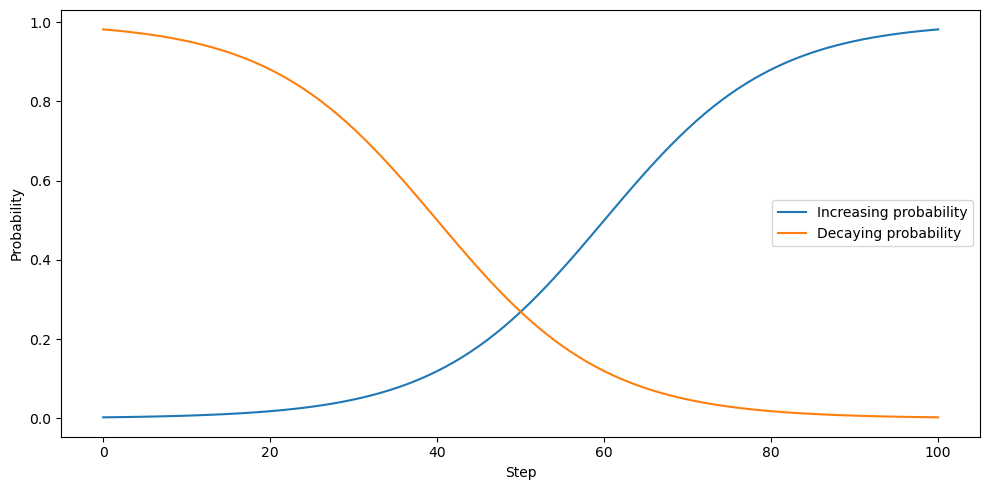

In [114]:
# Exponentially decaying and increasing probabilities with some overlap in the middle
steps = 100

p_1_list = []
p_2_list = []
for step_i in range(steps + 1):
    # The increasing probability
    p_1 = sigmoid_function(step_i / steps, center=0.6, steepness=10)
    
    # The decaying probability
    p_2 = 1 - sigmoid_function(step_i / steps, center=0.4, steepness=10)
    
    p_1_list.append(p_1)
    p_2_list.append(p_2)
    
# Plot the probabilities
plt.figure(figsize=(10, 5))
plt.plot(p_1_list, label='Increasing probability')
plt.plot(p_2_list, label='Decaying probability')
plt.legend()
plt.xlabel('Step')
plt.ylabel('Probability')

plt.tight_layout()
plt.show()

In [113]:
p_2_list[10]

0.9644288107273639

In [ ]:
# Show length of interpolated lists
index_to_show = 45
print(len(interpolated_cell_parameters_list[index_to_show]), len(interpolated_atoms_list[index_to_show]), len(interpolated_positions_list[index_to_show]))

6 55 55


In [ ]:
index_to_show = 35

test_structure = Atoms(
    cell=interpolated_cell_parameters_list[index_to_show],
    scaled_positions=interpolated_positions_list[index_to_show],
    numbers=interpolated_atoms_list[index_to_show],
)

view(test_structure, viewer='ngl')

In [ ]:
# Visualize the rock salt structure
# view(rocksalt_structure, viewer='ngl', repeat=(2,2,2))

In [ ]:
# view(spinel_structure, viewer='ngl')

In [ ]:
# view(zincblende_structure, viewer='ngl', repeat=(2,2,2))

In [ ]:
# Count the number of O atoms in the rock salt structure
rocksalt_n_O = sum(rocksalt_structure.get_atomic_numbers() == 8)
print(f'Number of O atoms in the rock salt structure: {rocksalt_n_O}')

# Count the number of O atoms in a 2x2x2 supercell of the rock salt structure
rocksalt_supercell = make_supercell(rocksalt_structure, np.diag([2, 2, 2]))
rocksalt_n_O_supercell = sum(rocksalt_supercell.get_atomic_numbers() == 8)
print(f'Number of O atoms in a 2x2x2 supercell of the rock salt structure: {rocksalt_n_O_supercell}')

# Count the number of O atoms in the spinel structure
spinel_n_O = sum(spinel_structure.get_atomic_numbers() == 8)
print(f'Number of O atoms in the spinel structure: {spinel_n_O}')

# Count the number of O atoms in the zinc blende structure
zincblende_n_O = sum(zincblende_structure.get_atomic_numbers() == 8)
print(f'Number of O atoms in the zinc blende structure: {zincblende_n_O}')

# Count the number of O atoms in a 2x2x2 supercell of the zinc blende structure
zincblende_supercell = make_supercell(zincblende_structure, np.diag([2, 2, 2]))
zincblende_n_O_supercell = sum(zincblende_supercell.get_atomic_numbers() == 8)
print(f'Number of O atoms in a 2x2x2 supercell of the zinc blende structure: {zincblende_n_O_supercell}')

Number of O atoms in the rock salt structure: 4
Number of O atoms in a 2x2x2 supercell of the rock salt structure: 32
Number of O atoms in the spinel structure: 32
Number of O atoms in the zinc blende structure: 4
Number of O atoms in a 2x2x2 supercell of the zinc blende structure: 32


In [ ]:
# Show the scaled positions of the O atoms in the rock salt structure
rocksalt_O_mask = rocksalt_supercell.get_atomic_numbers() == 8
rocksalt_O_positions = rocksalt_supercell.get_scaled_positions()[rocksalt_O_mask]
rocksalt_O_positions

array([[0.25, 0.25, 0.25],
       [0.25, 0.  , 0.  ],
       [0.  , 0.25, 0.  ],
       [0.  , 0.  , 0.25],
       [0.25, 0.25, 0.75],
       [0.25, 0.  , 0.5 ],
       [0.  , 0.25, 0.5 ],
       [0.  , 0.  , 0.75],
       [0.25, 0.75, 0.25],
       [0.25, 0.5 , 0.  ],
       [0.  , 0.75, 0.  ],
       [0.  , 0.5 , 0.25],
       [0.25, 0.75, 0.75],
       [0.25, 0.5 , 0.5 ],
       [0.  , 0.75, 0.5 ],
       [0.  , 0.5 , 0.75],
       [0.75, 0.25, 0.25],
       [0.75, 0.  , 0.  ],
       [0.5 , 0.25, 0.  ],
       [0.5 , 0.  , 0.25],
       [0.75, 0.25, 0.75],
       [0.75, 0.  , 0.5 ],
       [0.5 , 0.25, 0.5 ],
       [0.5 , 0.  , 0.75],
       [0.75, 0.75, 0.25],
       [0.75, 0.5 , 0.  ],
       [0.5 , 0.75, 0.  ],
       [0.5 , 0.5 , 0.25],
       [0.75, 0.75, 0.75],
       [0.75, 0.5 , 0.5 ],
       [0.5 , 0.75, 0.5 ],
       [0.5 , 0.5 , 0.75]])

In [ ]:
# Show the scaled positions of the O atoms in the spinel structure
spinel_O_mask = spinel_structure.get_atomic_numbers() == 8
spinel_O_positions = spinel_structure.get_scaled_positions()[spinel_O_mask]
spinel_O_positions

array([[0.3626, 0.3626, 0.3626],
       [0.6374, 0.1374, 0.8626],
       [0.1374, 0.8626, 0.6374],
       [0.8626, 0.6374, 0.1374],
       [0.1126, 0.6126, 0.3874],
       [0.8874, 0.8874, 0.8874],
       [0.6126, 0.3874, 0.1126],
       [0.3874, 0.1126, 0.6126],
       [0.6126, 0.1126, 0.3874],
       [0.1126, 0.3874, 0.6126],
       [0.3874, 0.6126, 0.1126],
       [0.1374, 0.6374, 0.8626],
       [0.6374, 0.8626, 0.1374],
       [0.8626, 0.1374, 0.6374],
       [0.3626, 0.8626, 0.8626],
       [0.6374, 0.6374, 0.3626],
       [0.1374, 0.3626, 0.1374],
       [0.1126, 0.1126, 0.8874],
       [0.8874, 0.3874, 0.3874],
       [0.6126, 0.8874, 0.6126],
       [0.6126, 0.6126, 0.8874],
       [0.1126, 0.8874, 0.1126],
       [0.1374, 0.1374, 0.3626],
       [0.6374, 0.3626, 0.6374],
       [0.8626, 0.3626, 0.8626],
       [0.3626, 0.6374, 0.6374],
       [0.3874, 0.8874, 0.3874],
       [0.8874, 0.1126, 0.1126],
       [0.8874, 0.6126, 0.6126],
       [0.3626, 0.1374, 0.1374],
       [0.

In [ ]:
# Show the scaled positions of the O atoms in the zinc blende structure
zincblende_O_mask = zincblende_supercell.get_atomic_numbers() == 8
zincblende_O_positions = zincblende_supercell.get_scaled_positions()[zincblende_O_mask]
zincblende_O_positions

array([[0.125, 0.125, 0.125],
       [0.375, 0.375, 0.125],
       [0.375, 0.125, 0.375],
       [0.125, 0.375, 0.375],
       [0.125, 0.125, 0.625],
       [0.375, 0.375, 0.625],
       [0.375, 0.125, 0.875],
       [0.125, 0.375, 0.875],
       [0.125, 0.625, 0.125],
       [0.375, 0.875, 0.125],
       [0.375, 0.625, 0.375],
       [0.125, 0.875, 0.375],
       [0.125, 0.625, 0.625],
       [0.375, 0.875, 0.625],
       [0.375, 0.625, 0.875],
       [0.125, 0.875, 0.875],
       [0.625, 0.125, 0.125],
       [0.875, 0.375, 0.125],
       [0.875, 0.125, 0.375],
       [0.625, 0.375, 0.375],
       [0.625, 0.125, 0.625],
       [0.875, 0.375, 0.625],
       [0.875, 0.125, 0.875],
       [0.625, 0.375, 0.875],
       [0.625, 0.625, 0.125],
       [0.875, 0.875, 0.125],
       [0.875, 0.625, 0.375],
       [0.625, 0.875, 0.375],
       [0.625, 0.625, 0.625],
       [0.875, 0.875, 0.625],
       [0.875, 0.625, 0.875],
       [0.625, 0.875, 0.875]])

In [ ]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

# Create a DataFrame for the O positions in the rock salt structure
rocksalt_O_df = pd.DataFrame(rocksalt_O_positions + 0.250, columns=['x', 'y', 'z'])
rocksalt_O_df['structure'] = 'Rock Salt'

# Create a DataFrame for the O positions in the spinel structure
spinel_O_df = pd.DataFrame(spinel_O_positions + 0.125, columns=['x', 'y', 'z'])
spinel_O_df['structure'] = 'Spinel'

# Create a DataFrame for the O positions in the zinc blende structure
zincblende_O_df = pd.DataFrame(1 - zincblende_O_positions + 0.125, columns=['x', 'y', 'z'])
zincblende_O_df['structure'] = 'Zinc Blende'

# Concatenate the DataFrames
O_df = pd.concat([rocksalt_O_df, spinel_O_df, zincblende_O_df])

In [ ]:
# Create a 3d scatter plot
fig = px.scatter_3d(O_df, x='x', y='y', z='z', color='structure', title='Oxygen positions in different structures')
fig.show()

# Filling holes (Fluorite --> Caesium Chloride)

# Removal of layer (Nickel Arsenide --> Cadmium Iodide)

In [2]:
# Read in the structures


# Nickel Arsenide structure
nickelArsenide_structures = [str(filepath) for filepath in Path('./data/CIFs/').rglob('NickelArsenide*.cif')]
nickelArsenide_compositions = [filepath.split('/')[-1].split('_')[-1].split('.')[0] for filepath in nickelArsenide_structures]
nickelArsenide_metals = [composition[:-1] for composition in nickelArsenide_compositions]

# Cadmium Iodide structure
cadmiumIodide_structures = [str(filepath) for filepath in Path('./data/CIFs/').rglob('CadmiumIodide*.cif')]
cadmiumIodide_compositions = [filepath.split('/')[-1].split('_')[-1].split('.')[0] for filepath in cadmiumIodide_structures]
cadmiumIodide_metals = [composition[:-2] for composition in cadmiumIodide_compositions]

In [8]:
def nickelArsenide_transformation(nickelArsenide_unitcell, expansion_factor=2, translation=0.0, inversion=False):
    # Make a supercell of the unit cell
    nickelArsenide_supercell = make_supercell(nickelArsenide_unitcell, np.diag([expansion_factor, expansion_factor, expansion_factor]))

    if inversion:
        # Invert the atoms in the supercell
        nickelArsenide_supercell.set_scaled_positions(1 - nickelArsenide_supercell.get_scaled_positions())

    # Translate the atoms in the supercell
    nickelArsenide_supercell.set_scaled_positions(nickelArsenide_supercell.get_scaled_positions() + translation) 
    
    return nickelArsenide_supercell

def cadmiumIodide_transformation(cadmiumIodide_unitcell, expansion_factor=2, translation=0.0, inversion=False):
    # Make a supercell of the unit cell
    cadmiumIodide_supercell = make_supercell(cadmiumIodide_unitcell, np.diag([expansion_factor, expansion_factor, expansion_factor]))
    
    if inversion:
        # Invert the atoms in the supercell
        cadmiumIodide_supercell.set_scaled_positions(1 - cadmiumIodide_supercell.get_scaled_positions())
        
    # Translate the atoms in the supercell
    cadmiumIodide_supercell.set_scaled_positions(cadmiumIodide_supercell.get_scaled_positions() + translation)
    
    return cadmiumIodide_supercell

In [9]:
metal_of_interest = 'Fe'

# Nickel Arsenide
nickelArsenide_structure = read(nickelArsenide_structures[nickelArsenide_metals.index(metal_of_interest)])
nickelArsenide_transformed = nickelArsenide_transformation(nickelArsenide_structure)

# Cadmium Iodide
cadmiumIodide_structure = read(cadmiumIodide_structures[cadmiumIodide_metals.index(metal_of_interest)])
cadmiumIodide_transformed = cadmiumIodide_transformation(cadmiumIodide_structure)

In [11]:
# view([nickelArsenide_transformed, cadmiumIodide_transformed], viewer='ngl')

In [12]:
# Define interpolation functions for the structures
def nickelArsenide_to_cadmiumIodide(nickelArsenide_structure, cadmiumIodide_structure, interpolation_steps=5, atom_samples=5, identification_threshold=0.1):
    # Sort the atoms
    nickelArsenide_structure = ase_sort(nickelArsenide_structure, tags=nickelArsenide_structure.get_atomic_numbers())
    cadmiumIodide_structure = ase_sort(cadmiumIodide_structure, tags=cadmiumIodide_structure.get_atomic_numbers())    
    
    # Get cell parameters
    nickelArsenide_cell_parameters = nickelArsenide_structure.cell.cellpar()
    cadmiumIodide_cell_parameters = cadmiumIodide_structure.cell.cellpar()
    
    # Get the scaled positions of the atoms
    nickelArsenide_positions = nickelArsenide_structure.get_scaled_positions()
    cadmiumIodide_positions = cadmiumIodide_structure.get_scaled_positions()
    
    # Get the atomic numbers of the atoms
    nickelArsenide_atoms = nickelArsenide_structure.get_atomic_numbers()
    cadmiumIodide_atoms = cadmiumIodide_structure.get_atomic_numbers()
    
    # Find the positions of the oxygen atoms
    nickelArsenide_O_positions = nickelArsenide_positions[nickelArsenide_atoms == 8]
    cadmiumIodide_O_positions = cadmiumIodide_positions[cadmiumIodide_atoms == 8]
    
    # Sort the oxygen atoms by distance to the origo and then by coordinate TODO: Do this
    temp_O_df = pd.DataFrame(nickelArsenide_O_positions, columns=['x', 'y', 'z'])
    temp_O_df['distance'] = np.linalg.norm(nickelArsenide_O_positions, axis=1)
    nickelArsenide_O_positions = nickelArsenide_O_positions[temp_O_df.sort_values(['distance', 'x', 'y', 'z']).index]
    
    temp_O_df = pd.DataFrame(cadmiumIodide_O_positions, columns=['x', 'y', 'z'])
    temp_O_df['distance'] = np.linalg.norm(cadmiumIodide_O_positions, axis=1)
    cadmiumIodide_O_positions = cadmiumIodide_O_positions[temp_O_df.sort_values(['distance', 'x', 'y', 'z']).index]

    del temp_O_df
    
    # Find the positions of the metal atoms
    nickelArsenide_M_positions = nickelArsenide_positions[nickelArsenide_atoms != 8]
    cadmiumIodide_M_positions = cadmiumIodide_positions[cadmiumIodide_atoms != 8]
    
    # Structure metallic element
    metallic_element = nickelArsenide_structure.get_atomic_numbers()[-1]
    
    # Find the metal atoms that are in both the nickelArsenide structure and the cadmiumIodide structure
    nickelArsenide_common_M_positions = []
    cadmiumIodide_common_M_positions = []
    for index in range(len(nickelArsenide_M_positions)):
        distances = np.linalg.norm(cadmiumIodide_M_positions - nickelArsenide_M_positions[index], axis=1)
        if np.min(distances) < identification_threshold:
            nickelArsenide_common_M_positions.append(index)
            cadmiumIodide_common_M_positions.append(np.argmin(distances))
    
    nickelArsenide_different_M_positions = [index for index in range(len(nickelArsenide_M_positions)) if index not in nickelArsenide_common_M_positions]
    cadmiumIodide_different_M_positions = [index for index in range(len(cadmiumIodide_M_positions)) if index not in cadmiumIodide_common_M_positions]
    
    interp_step_list = []
    sample_i_list = []
    interpolated_cell_parameters_list = []
    interpolated_atoms_list = []
    interpolated_positions_list = []
    for interp_step_i in range(interpolation_steps + 1):
        if interp_step_i == 0:
            # Save the nickelArsenide structure
            interp_step_list.append(interp_step_i)
            sample_i_list.append(0)
            interpolated_cell_parameters_list.append(nickelArsenide_cell_parameters)
            interpolated_atoms_list.append(nickelArsenide_atoms)
            interpolated_positions_list.append(nickelArsenide_positions)
            continue
        elif interp_step_i == interpolation_steps:
            # Save the cadmiumIodide structure
            interp_step_list.append(interp_step_i)
            sample_i_list.append(0)
            interpolated_cell_parameters_list.append(cadmiumIodide_cell_parameters)
            interpolated_atoms_list.append(cadmiumIodide_atoms)
            interpolated_positions_list.append(cadmiumIodide_positions)
            continue
        else:
            # Interpolate the cell parameters 
            interpolated_cell_parameters = nickelArsenide_cell_parameters + ((cadmiumIodide_cell_parameters - nickelArsenide_cell_parameters) * interp_step_i / interpolation_steps)
            
            # Interpolate the positions of oxygens
            interpolated_O_positions = nickelArsenide_O_positions + ((cadmiumIodide_O_positions - nickelArsenide_O_positions) * interp_step_i / interpolation_steps)
            
            # Interpolate the positions of the common metal atoms
            interpolated_common_M_positions = nickelArsenide_M_positions[nickelArsenide_common_M_positions] + ((cadmiumIodide_M_positions[cadmiumIodide_common_M_positions] - nickelArsenide_M_positions[nickelArsenide_common_M_positions]) * interp_step_i / interpolation_steps)
            
            for sample_i in range(atom_samples):                            
                # Non-shared metal atoms from nickel arsenide to keep
                n_nickelArsenide_different_M_positions = len(nickelArsenide_different_M_positions)
                
                # sigmoid probability for keeping an atom
                p_1 = 1 - (interp_step_i / interpolation_steps)
                
                nickelArsenide_indeces_to_keep = np.where(np.random.random(n_nickelArsenide_different_M_positions) < p_1)[0]

                interpolated_different_M_positions = nickelArsenide_M_positions[nickelArsenide_different_M_positions][nickelArsenide_indeces_to_keep]
                
                # Construct the interpolated structure
                interpolated_atoms = np.concatenate(
                    [
                        [8] * len(interpolated_O_positions),
                        [metallic_element] * len(interpolated_common_M_positions),
                        [metallic_element] * len(interpolated_different_M_positions)
                        ]
                    )
                interpolated_positions = np.concatenate(
                    [
                        interpolated_O_positions, 
                        interpolated_common_M_positions, 
                        interpolated_different_M_positions, 
                    ]
                )
                
                # Save the interpolated structure
                interp_step_list.append(interp_step_i)
                sample_i_list.append(sample_i)
                interpolated_cell_parameters_list.append(interpolated_cell_parameters)
                interpolated_atoms_list.append(interpolated_atoms)
                interpolated_positions_list.append(interpolated_positions)  
        
    return interp_step_list, sample_i_list, interpolated_cell_parameters_list, interpolated_atoms_list, interpolated_positions_list


In [13]:
# Define save folder
save_folder = './data/CIFs/Interpolations_v2/'

Path(save_folder).mkdir(parents=True, exist_ok=True)

# Determine random seed
seed = 42
np.random.seed(seed)

# Generate nickelArsenide to cadmiumIodide interpolations
interp_step_list, sample_i_list, interpolated_cell_parameters_list, interpolated_atoms_list, interpolated_positions_list = nickelArsenide_to_cadmiumIodide(nickelArsenide_transformed, cadmiumIodide_transformed, identification_threshold=0.1)

# Check for and remove duplicate structures
duplicate_indices = []
for i in range(len(interp_step_list)):
    for j in range(i, len(interp_step_list)):
        if i == j:
            continue
        if np.array_equal(interpolated_positions_list[i], interpolated_positions_list[j]) and np.array_equal(interpolated_cell_parameters_list[i], interpolated_cell_parameters_list[j]):
            if j == len(interp_step_list) - 1:
                duplicate_indices.append(i)
            else:
                duplicate_indices.append(j)

interp_step_list = [interp_step_list[i] for i in range(len(interp_step_list)) if i not in duplicate_indices]
sample_i_list = [sample_i_list[i] for i in range(len(sample_i_list)) if i not in duplicate_indices]
interpolated_cell_parameters_list = [interpolated_cell_parameters_list[i] for i in range(len(interpolated_cell_parameters_list)) if i not in duplicate_indices]
interpolated_atoms_list = [interpolated_atoms_list[i] for i in range(len(interpolated_atoms_list)) if i not in duplicate_indices]
interpolated_positions_list = [interpolated_positions_list[i] for i in range(len(interpolated_positions_list)) if i not in duplicate_indices]

print(f"Removed {len(duplicate_indices)} duplicate structures")


# Save interpolations as cif files
for interpolation_i in range(len(interp_step_list)):
    interpolated_structure = Atoms(
        cell=interpolated_cell_parameters_list[interpolation_i],
        scaled_positions=interpolated_positions_list[interpolation_i],
        numbers=interpolated_atoms_list[interpolation_i],
        pbc=True,
    )
    if interpolation_i == 0:
        write(f'{save_folder}NickelArsenide.cif', interpolated_structure)
    elif interpolation_i == len(interp_step_list) - 1:
        write(f'{save_folder}CadmiumIodide.cif', interpolated_structure)
    else:
        write(f'{save_folder}interpolated_NickelArsenide_to_CadmiumIodide_step{interp_step_list[interpolation_i]}_sample{sample_i_list[interpolation_i]}.cif', interpolated_structure)

Removed 1 duplicate structures


# Layer stacking (Cadmium Chloride --> Cadmium Iodide)